# 실습 5-2 : SHAP Value

#### **<실습 내용>**

1. SHAP - 회귀 모델 (Regression)
- TreeExplainer를 사용한 SHAP 분석
- Summary Plot / Force Plot / Dependence Plot

3. SHAP - 분류 모델 (Classification)
- TreeExplainer를 사용한 SHAP 분석
- Summary Plot / Force Plot / Dependence Plot

## 분석 준비

### 주요 라이브러리 호출

In [1]:
!pip install shap

   ---------------------------------------- 0.0/547.2 kB ? eta -:--:--
   ---------------------------------------- 547.2/547.2 kB 9.2 MB/s  0:00:00
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 2.7/2.7 MB 11.9 MB/s  0:00:00
   ---------------------------------------- 0.0/28.1 MB ? eta -:--:--
   ------ --------------------------------- 4.7/28.1 MB 25.9 MB/s eta 0:00:01
   --------------- ------------------------ 10.7/28.1 MB 26.9 MB/s eta 0:00:01
   ---------------------- ----------------- 15.7/28.1 MB 25.4 MB/s eta 0:00:01
   ----------------------------- ---------- 20.7/28.1 MB 25.2 MB/s eta 0:00:01
   ------------------------------------ --- 25.4/28.1 MB 24.8 MB/s eta 0:00:01
   ---------------------------------------  28.0/28.1 MB 24.0 MB/s eta 0:00:01
   ---------------------------------------- 28.1/28.1 MB 22.0 MB/s  0:00:01

   -------- ------------------------------- 1/5 [llvmlite]
   -------- ------------------

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, accuracy_score, f1_score
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)

import shap

c:\Users\Admin\miniconda3\envs\day2\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---

## 1) SHAP - 회귀 모델

In [3]:
# 회귀 성능 평가 함수
def get_regscore(true, pred):
    print("MSE       : %.3f" % mean_squared_error(true, pred))
    print("RMSE      : %.3f" % np.sqrt(mean_squared_error(true, pred)))
    print("MAE       : %.3f" % mean_absolute_error(true, pred))
    print("R-squared : %.3f" % r2_score(true, pred))

### 1-1) 데이터 및 모델 준비

In [4]:
Regression = pd.read_csv("dataset/day5-2_reg_data.csv")
Regression

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X50,X51,X52,X53,X54,X55,X56,X57,X58,y
0,0.40420,0.39615,0.34470,0.39535,0.44180,0.38830,0.36245,0.34480,0.32475,0.38020,...,0.39200,0.34985,0.37980,0.42355,0.38990,0.40890,0.41720,0.37765,0.36190,48.272178
1,0.47115,0.35280,0.29120,0.30190,0.54875,0.40430,0.42125,0.32620,0.35280,0.43115,...,0.32080,0.35185,0.35570,0.38400,0.44375,0.25945,0.55030,0.43205,0.31395,49.767621
2,0.31185,0.35220,0.41940,0.38370,0.30015,0.32555,0.39790,0.44730,0.55625,0.60885,...,0.36105,0.36230,0.30455,0.26945,0.49770,0.37425,0.27800,0.41980,0.37620,45.512356
3,0.43900,0.38300,0.38830,0.33920,0.40740,0.40650,0.45455,0.40565,0.41915,0.33565,...,0.33715,0.46605,0.45040,0.37150,0.37625,0.28595,0.45195,0.40570,0.39885,55.646432
4,0.38005,0.42835,0.53105,0.39145,0.31755,0.40365,0.33230,0.48530,0.44295,0.37615,...,0.43555,0.30330,0.26910,0.35155,0.42230,0.43660,0.35875,0.43605,0.46260,47.703096
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236,0.40675,0.37110,0.29385,0.37125,0.43345,0.32380,0.40365,0.32200,0.35655,0.50940,...,0.31965,0.32385,0.37480,0.37240,0.46065,0.33660,0.40075,0.37875,0.30040,44.683854
237,0.37940,0.36660,0.39205,0.42100,0.37860,0.42690,0.39580,0.39240,0.39080,0.35705,...,0.43260,0.40485,0.36410,0.45070,0.37270,0.45270,0.36685,0.39055,0.40395,47.907255
238,0.35150,0.35285,0.24365,0.40190,0.50055,0.37125,0.36820,0.28830,0.34130,0.48590,...,0.38300,0.38705,0.41305,0.40750,0.39510,0.40895,0.40825,0.35865,0.30240,45.900853
239,0.30580,0.46180,0.50870,0.43220,0.38695,0.43260,0.24155,0.45805,0.38565,0.29875,...,0.51305,0.36490,0.35580,0.36160,0.31170,0.53040,0.36960,0.38475,0.49090,51.418961


In [5]:
X_reg = Regression.drop(["y"], axis=1) # 입력변수
Y_reg = Regression["y"] # 출력변수

X_train_reg, X_test_reg, Y_train_reg, Y_test_reg = train_test_split(X_reg, Y_reg, test_size=0.2, random_state=42) # 학습/테스트 데이터 분할

In [6]:
rf_reg = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=0) # RandomForest로 모델 학습
rf_reg.fit(X_train_reg, Y_train_reg)
Y_pred_reg = rf_reg.predict(X_test_reg)
get_regscore(Y_test_reg, Y_pred_reg)

MSE       : 6.592
RMSE      : 2.568
MAE       : 1.991
R-squared : 0.558


### 2-2) SHAP 분석

In [7]:
# rf_reg 모델을 해석하기 위한 SHAP 설명자 생성
explainer_reg = shap.TreeExplainer(rf_reg)

# 학습 데이터(X_train_reg)에 대한 SHAP value 계산
# 각 feature가 예측값에 기여하는 정도를 나타냄
shap_values_reg = explainer_reg.shap_values(X_train_reg)

#### Summary Plot (Bar)
- 막대가 길수록 예측에 영향을 많이 주는 변수라는 뜻임

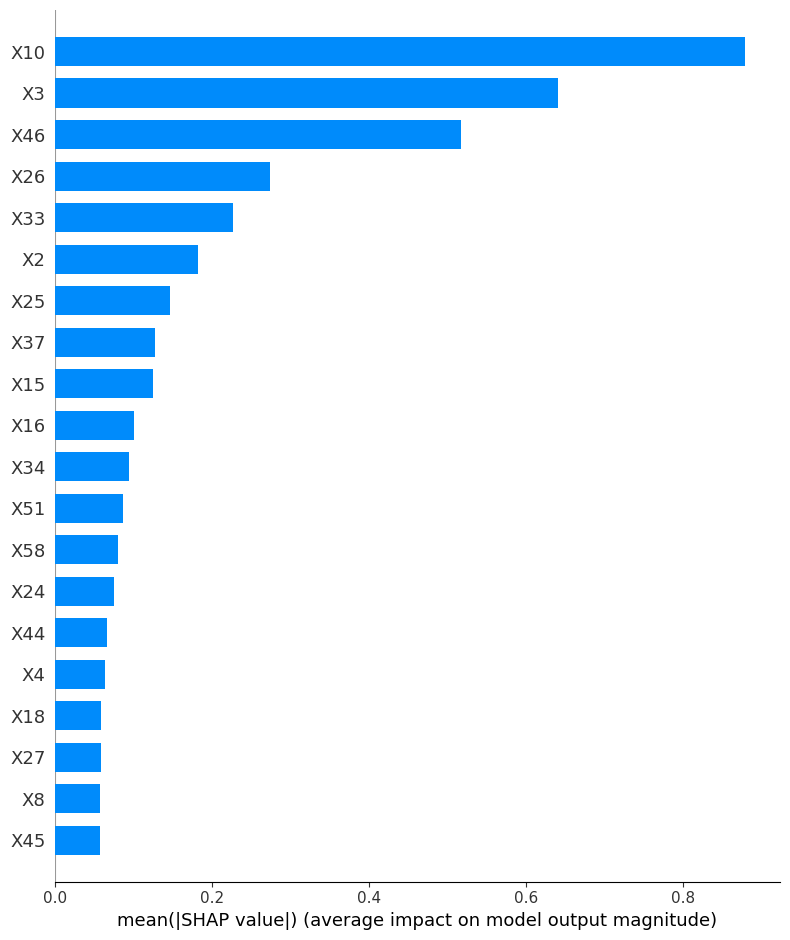

In [8]:
shap.summary_plot(shap_values_reg, X_train_reg, plot_type='bar')

#### Summary Plot (Scatter)
- 오른쪽에 점이 몰려있으면 예측값을 올리는 변수, 왼쪽에 몰려있으면 예측값을 낮추는 변수임

> - 빨간색: 높은 변수 값
> - 파란색: 낮은 변수 값

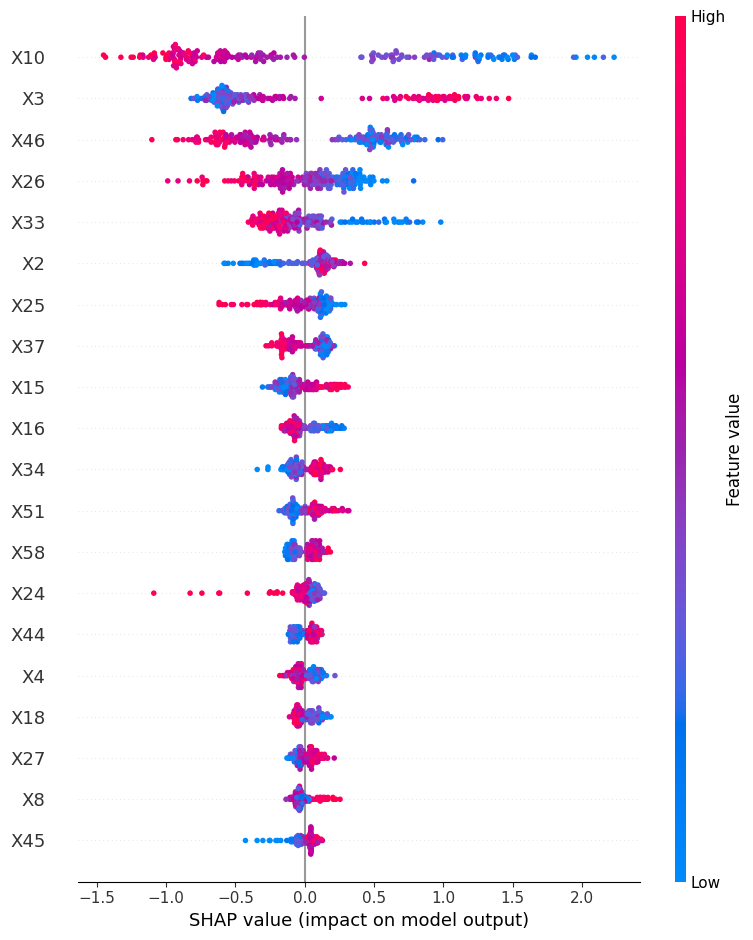

In [9]:
shap.summary_plot(shap_values_reg, X_train_reg)

#### Force Plot (개별 데이터)
- 데이터 하나를 뽑아서 어떤 변수가 예측값을 올렸고 내렸는지 화살표로 보여주는 그래프임

In [10]:
base_value_reg = explainer_reg.expected_value
print(base_value_reg)

[49.74460342]


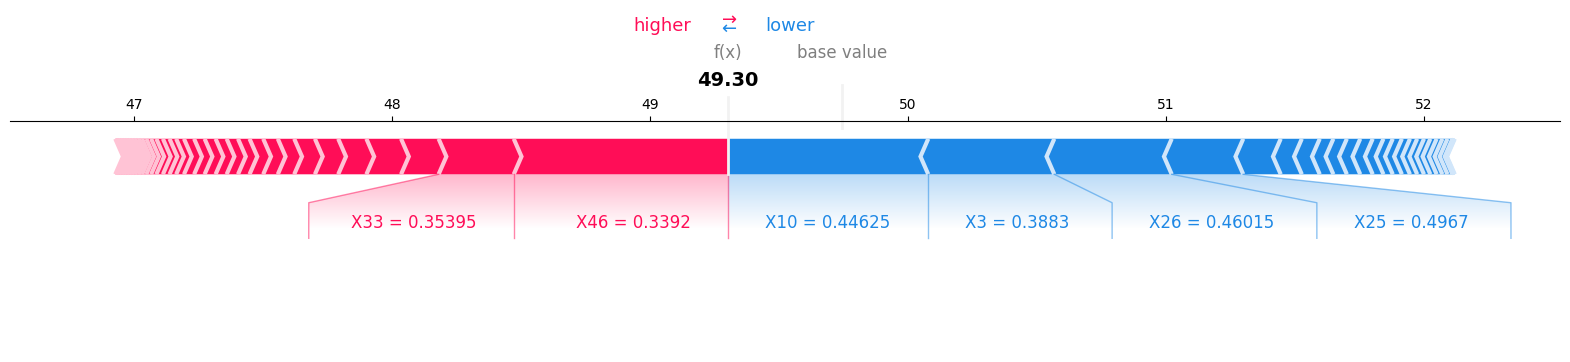

In [11]:
# 첫 번째 데이터(index 0)의 예측 결과를 force plot으로 시각화
# expected_value: 전체 데이터의 평균 예측값 (기준선)
# shap_values_reg[0]: 이 데이터의 각 feature별 SHAP value 
# X_train_reg.iloc[0]: 실제 feature 값들 (그래프에 표시용)

shap.force_plot(
    explainer_reg.expected_value,
    shap_values_reg[0],
    X_train_reg.iloc[0],
    matplotlib=True
)

#### Dependence Plot
- 변수 값이 변할 때 SHAP 값(영향력)이 같이 어떻게 움직이는지 보여주는 그래프임

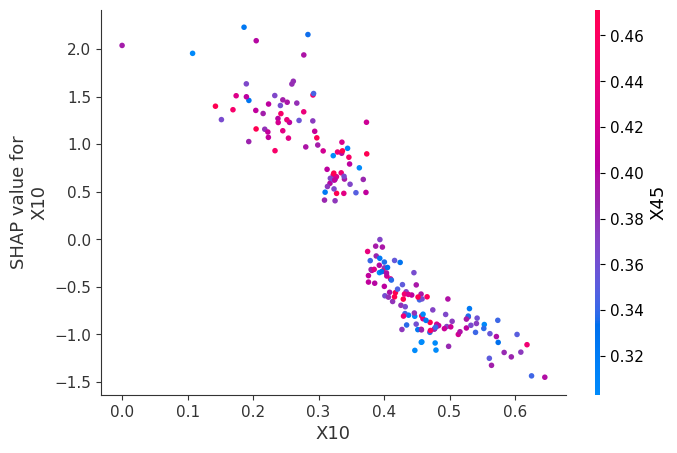

In [12]:
# "X10" feature 값에 따라 SHAP value가 어떻게 변하는지 시각화
# x축: X10의 실제 값, y축: X10의 SHAP value (예측에 미친 영향)
# 자동으로 X10과 가장 상호작용이 큰 feature를 색상으로 표시

shap.dependence_plot(
    "X10",
    shap_values_reg,
    X_train_reg
)

---

## 3) SHAP - 분류 모델

In [13]:
# 분류 성능 평가 함수
def get_classscore(real, pred):
    print("Accuracy  : %.3f" % accuracy_score(real, pred))
    print("Precision : %.3f" % precision_score(real, pred))
    print("Recall    : %.3f" % recall_score(real, pred))
    print("F1-score  : %.3f" % f1_score(real, pred))
    print()
    print("혼동행렬")
    print(confusion_matrix(real, pred))

### 3-1) 데이터 및 모델 준비

In [14]:
Classification = pd.read_csv("dataset/day5-2_cls_data.csv")
Classification

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X466,X467,X468,X469,X470,X471,X472,X473,X474,Y
0,0.457896,0.530189,0.276976,0.359864,0.193059,0.322190,0.706897,0.553781,0.653894,0.375204,...,0.246376,0.711806,0.008532,0.013672,0.008467,0.402240,0.238811,0.274876,0.210238,-1
1,0.607100,0.341478,0.518992,0.395300,0.042071,0.469654,0.750000,0.542031,0.447466,0.189233,...,0.523785,0.760417,0.030930,0.033203,0.029759,0.210356,0.309339,0.328358,0.439175,-1
2,0.360781,0.369653,0.341039,0.021697,0.181737,0.528684,0.491379,0.516722,0.300371,0.376835,...,0.185769,0.659722,0.005333,0.003906,0.005311,0.381877,0.208171,0.208955,0.155761,-1
3,0.460910,0.413500,0.535685,0.302794,0.242326,0.408966,0.646552,0.561615,0.415328,0.313214,...,0.246376,0.000000,1.000000,1.000000,1.000000,0.381877,0.208171,0.208955,0.155761,-1
4,0.263068,0.279821,0.535685,0.302794,0.242326,0.408966,0.646552,0.638747,0.660074,0.520392,...,0.110711,0.517361,0.023677,0.022461,0.023447,0.608414,0.212062,0.268657,0.092827,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249,0.360022,0.396033,0.382803,0.070771,0.143308,0.920884,0.586207,0.636336,0.337454,0.432300,...,0.000000,0.597222,0.016212,0.013672,0.015997,0.045307,0.147860,0.171642,0.000000,1
250,0.508628,0.437628,0.192378,0.061866,0.168425,0.481919,0.715517,0.270563,0.407911,0.336052,...,0.132582,0.975694,0.017065,0.015625,0.016114,0.543689,0.227626,0.320896,0.111165,1
251,0.275930,0.364365,0.302236,0.376615,0.485135,0.627270,0.594828,0.435673,0.420272,0.367047,...,0.246376,0.586806,0.008532,0.015625,0.008613,0.343042,0.151751,0.164179,0.143012,1
252,0.785179,0.271804,0.400189,0.457851,0.229526,0.244320,0.396552,0.875565,0.110012,0.337684,...,0.221768,0.767361,0.024317,0.019531,0.023461,0.509709,0.398833,0.440299,0.185945,1


In [15]:
X_cls = Classification.drop(["Y"], axis=1) # 입력변수
Y_cls = Classification["Y"] # 출력변수

X_train_cls, X_test_cls, Y_train_cls, Y_test_cls = train_test_split(
    X_cls, Y_cls, test_size=0.2, random_state=123, stratify=Y_cls)

rf_cls = RandomForestClassifier(n_estimators=100, random_state=0)
rf_cls.fit(X_train_cls, Y_train_cls)
Y_pred_cls = rf_cls.predict(X_test_cls)
get_classscore(Y_test_cls, Y_pred_cls)

Accuracy  : 0.863
Precision : 0.938
Recall    : 0.714
F1-score  : 0.811

혼동행렬
[[29  1]
 [ 6 15]]


### 3-2) SHAP 분석

In [16]:
explainer_cls = shap.TreeExplainer(rf_cls)
shap_values_cls = explainer_cls.shap_values(X_train_cls)

#### Summary Plot (Bar)

> 분류 모델의 경우 `shap_values_cls`는 (샘플 수, 변수 수, 클래스 수) 형태의 3차원 배열임
> - `shap_values_cls[:, :, 0]`: 클래스 -1에 대한 SHAP
> - `shap_values_cls[:, :, 1]`: 클래스 1에 대한 SHAP

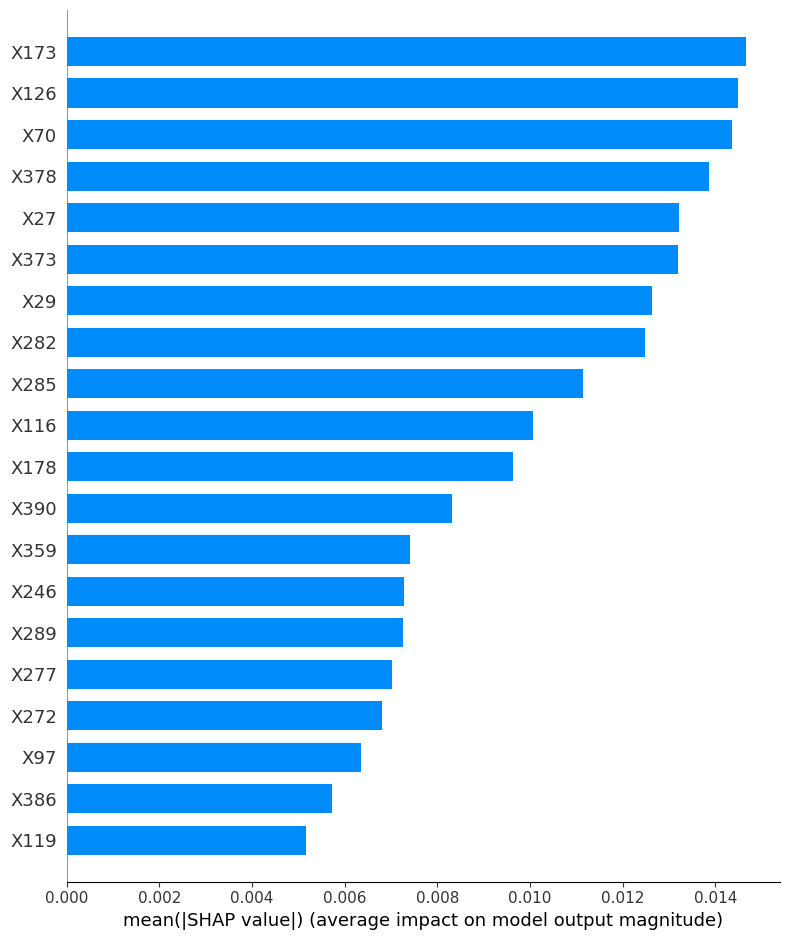

In [17]:
shap.summary_plot(shap_values_cls[:, :, 0], X_train_cls, plot_type='bar')  # 클래스 -1 기준

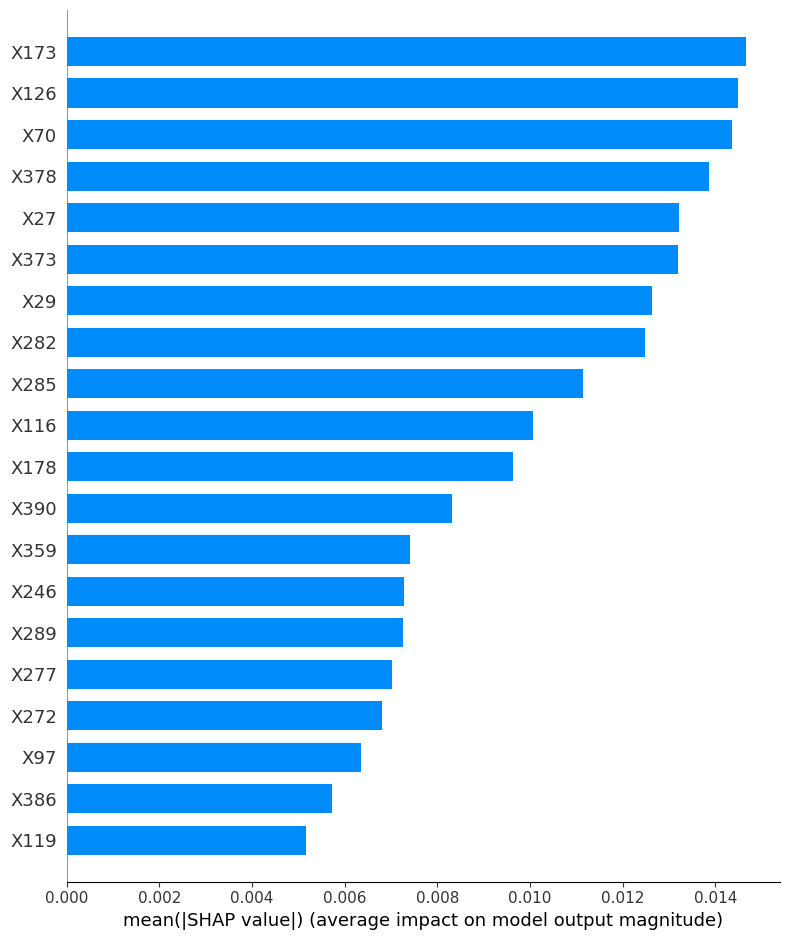

In [18]:
shap.summary_plot(shap_values_cls[:, :, 1], X_train_cls, plot_type='bar')  # 클래스 1 기준

#### Summary Plot (Scatter) - 클래스별

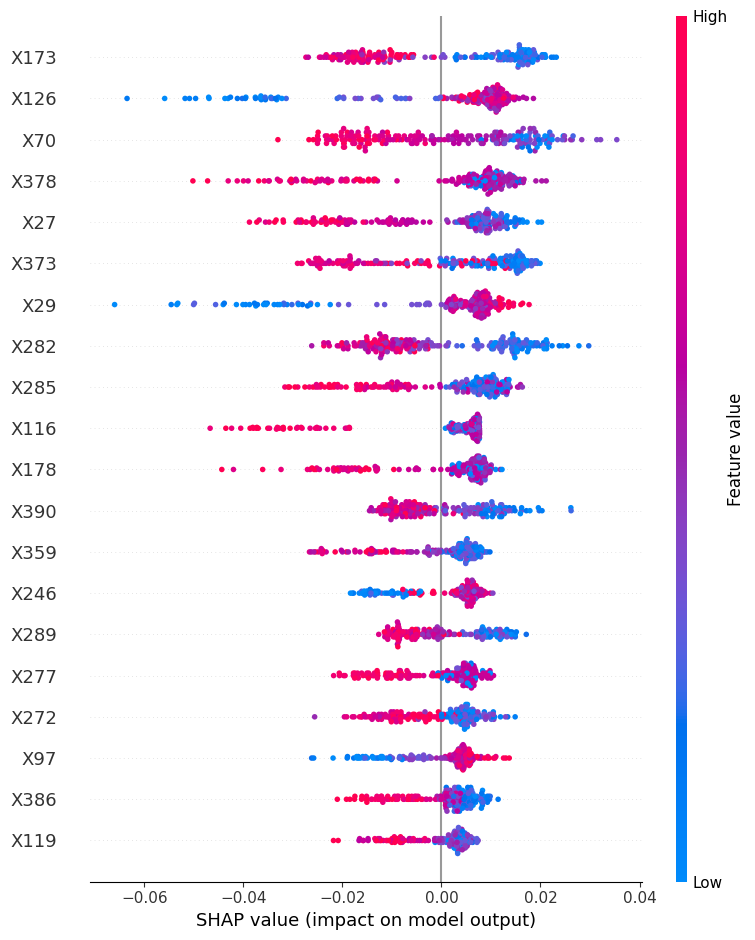

In [19]:
shap.summary_plot(shap_values_cls[:, :, 0], X_train_cls) # 클래스 = -1

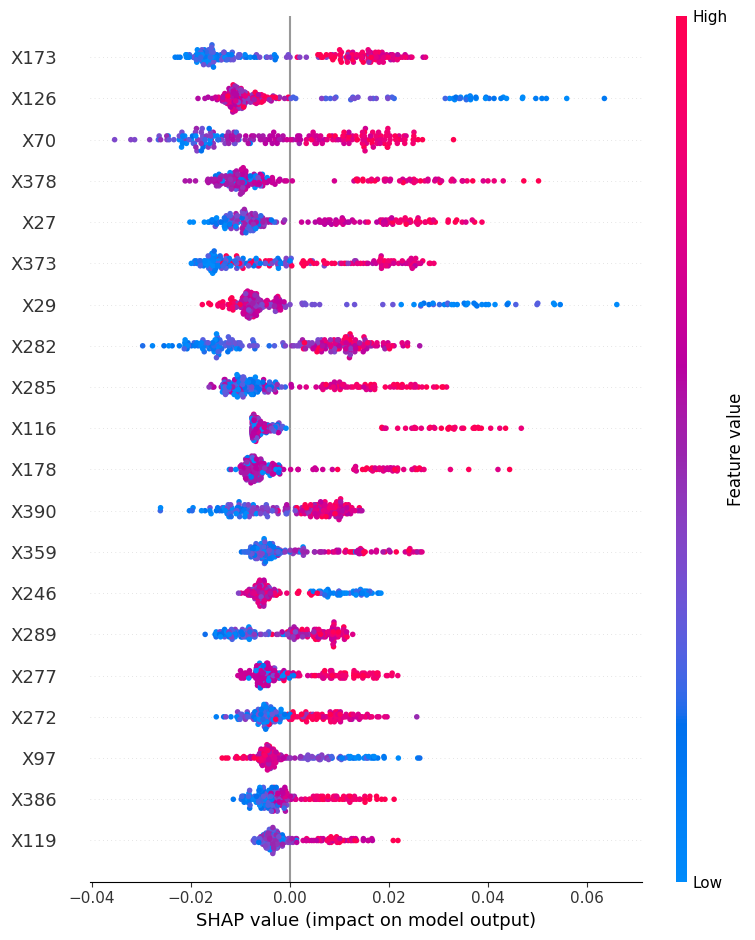

In [20]:
# 변수 중요도 순서는 같은데 부호가 반대 방향임

shap.summary_plot(shap_values_cls[:, :, 1], X_train_cls) # 클래스 = 1

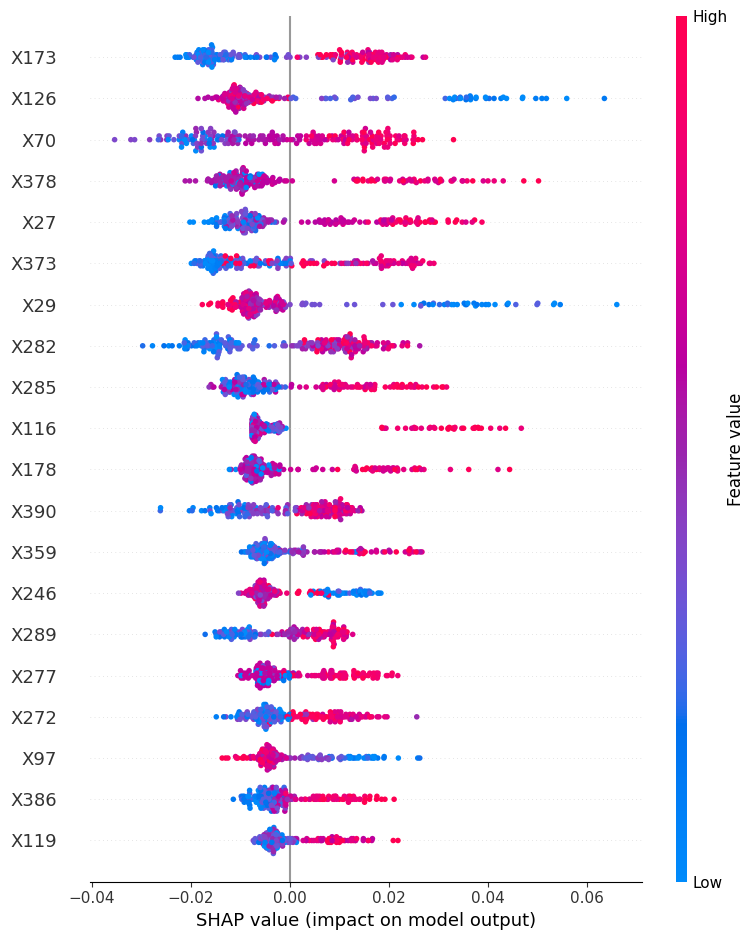

In [21]:
shap.summary_plot(shap_values_cls[:, :, 1], X_train_cls)

#### Force Plot (개별 데이터)

In [22]:
# 15번 데이터의 실제(정답) 클래스 확인
Y_train_cls.iloc[15]

np.int64(-1)

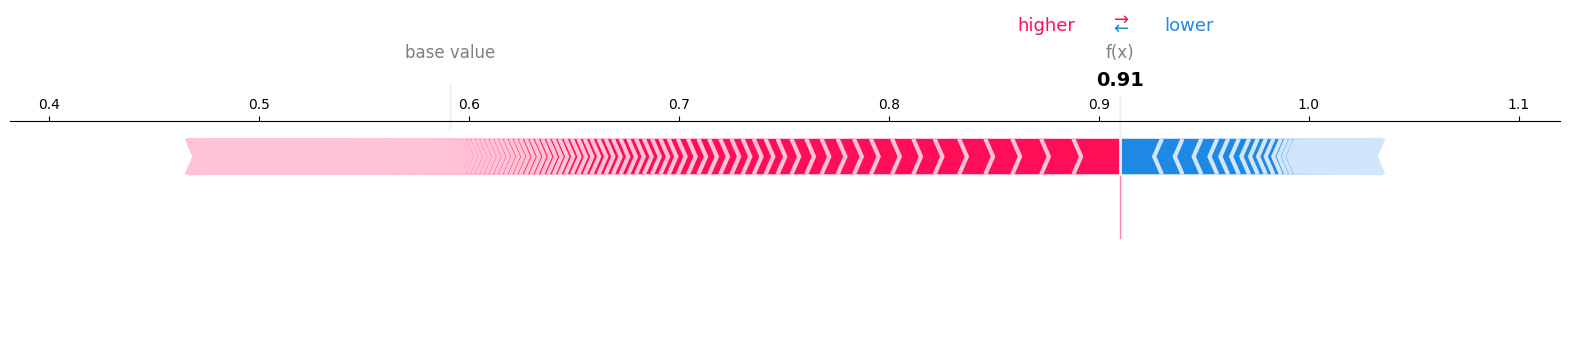

In [23]:
# 15번 데이터를 클래스 -1로 예측하는 데 각 feature가 어떻게 기여했는지 시각화

# expected_value[0]: 클래스 -1에 대한 기준값(base value)
# shap_values_cls[15, :, 0]: 15번 데이터의, 클래스 -1에 대한 각 feature별 SHAP value
# X_train_cls.iloc[15]: 15번 데이터의 실제 feature 값들 

shap.force_plot(
    explainer_cls.expected_value[0],
    shap_values_cls[15, :, 0],
    X_train_cls.iloc[15],
    matplotlib=True
)

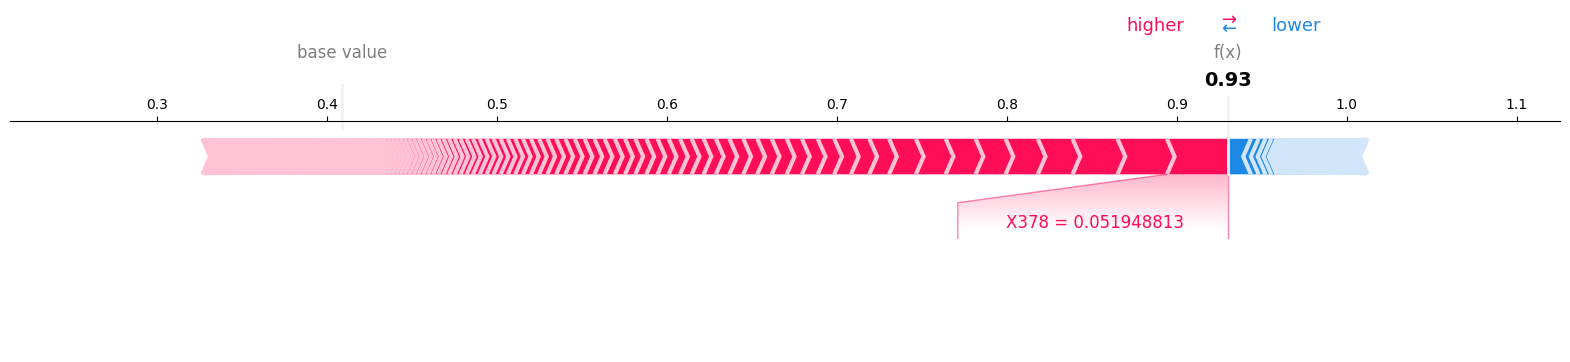

In [24]:
# 40번 데이터를 클래스 1로 예측하는 데 각 feature가 어떻게 기여했는지 시각화

# expected_value[1]: 클래스 1에 대한 기준값(base value)
# shap_values_cls[40, :, 1]: 40번 데이터의, 클래스 1에 대한 각 feature별 SHAP value
# X_train_cls.iloc[40]: 40번 데이터의 실제 feature 값들

shap.force_plot(
    explainer_cls.expected_value[1],
    shap_values_cls[40, :, 1],
    X_train_cls.iloc[40],
    matplotlib=True
)

#### Dependence Plot

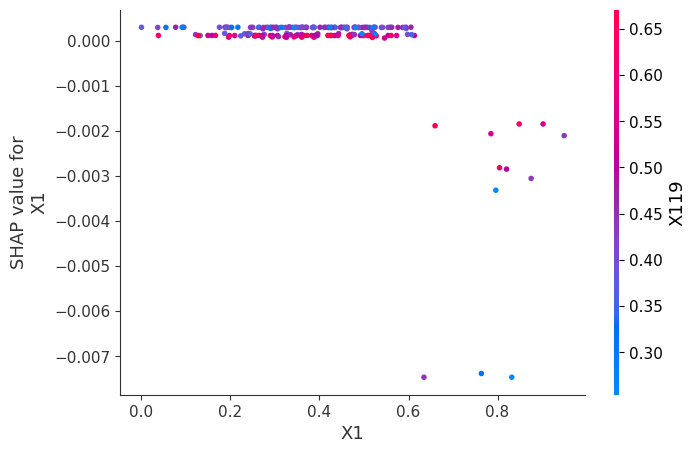

In [25]:
# "X1" feature 값에 따라, 클래스 -1에 대한 SHAP value가 어떻게 변하는지 시각화
# x축: X1의 실제 값, y축: X1의 클래스 -1 기준 SHAP value (예측에 미친 영향)
# 자동으로 X1과 가장 상호작용이 큰 feature를 색상으로 표시

shap.dependence_plot(
    "X1",
    shap_values_cls[:, :, 0],
    X_train_cls
)

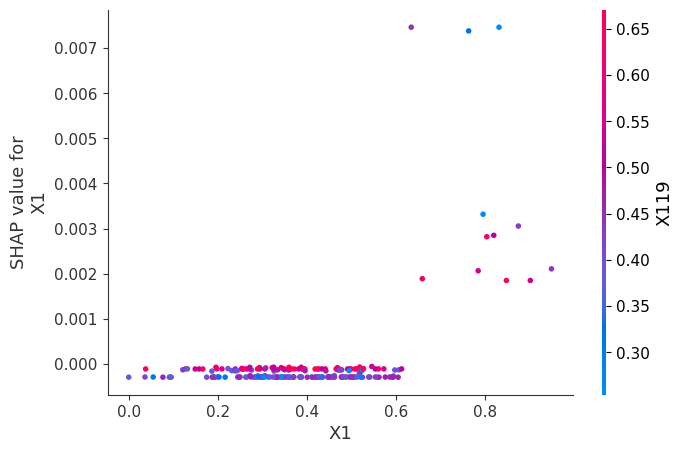

In [26]:
# "X1" feature 값에 따라, 클래스 1에 대한 SHAP value가 어떻게 변하는지 시각화
# x축: X1의 실제 값, y축: X1의 클래스 1 기준 SHAP value (예측에 미친 영향)
# 자동으로 X1과 가장 상호작용이 큰 feature를 색상으로 표시

shap.dependence_plot(
    "X1",
    shap_values_cls[:, :, 1],
    X_train_cls
)

---

## 4) Vibe Coding 실습

**[과제 1]** 

지수는 Random Forest의 Feature Importance와 SHAP Value가 모두 변수의 중요도를 설명하는 방법이라는 것을 배웠습니다.

AI와 함께 Random Forest (회귀/분류)의 feature_importances_와 SHAP Summary Plot 결과를 비교해 보세요.

두 방법에서 중요하게 평가된 변수가 얼마나 비슷한지 확인하고 순위가 다른 변수는 왜 차이가 발생했는지 AI와 토의하여 해석해 보세요.


=== Regression ===
Top-10 overlap: 9/10 → ['X10', 'X15', 'X2', 'X25', 'X26', 'X3', 'X33', 'X37', 'X46']
Spearman rank correlation: 0.950


,Feature,RF_importance,Mean_|SHAP|,RF_rank,SHAP_rank
X10,X10,0.193025,0.879149,1,1
X3,X3,0.141376,0.640705,2,2
X46,X46,0.089514,0.516354,3,3
X26,X26,0.050647,0.273539,4,4
X33,X33,0.034804,0.226753,5,5
X2,X2,0.033480,0.181888,6,6
X25,X25,0.028282,0.146616,7,7
X37,X37,0.026450,0.127244,8,8
X15,X15,0.022193,0.124085,9,9
X16,X16,0.014284,0.100802,12,10


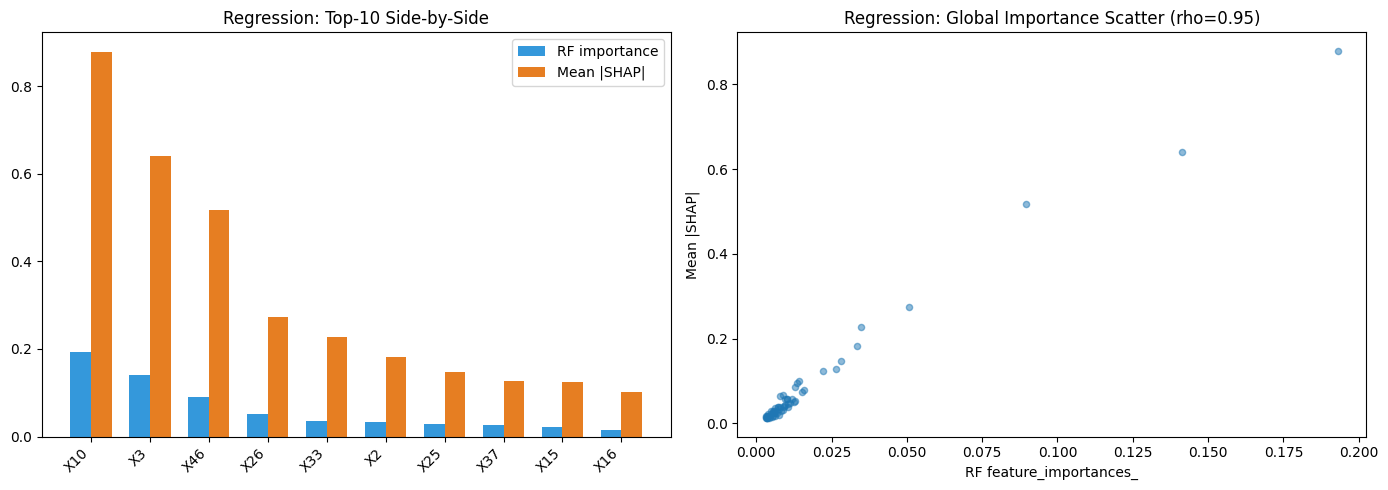


=== Classification (class 1) ===
Top-10 overlap: 9/10 → ['X126', 'X173', 'X27', 'X282', 'X285', 'X29', 'X373', 'X378', 'X70']
Spearman rank correlation: 0.963


,Feature,RF_importance,Mean_|SHAP|,RF_rank,SHAP_rank
X173,X173,0.016975,0.014662,8,1
X126,X126,0.022421,0.014494,2,2
X70,X70,0.021257,0.014354,3,3
X378,X378,0.019221,0.013869,5,4
X27,X27,0.018447,0.013207,6,5
X373,X373,0.024285,0.013201,1,6
X29,X29,0.021031,0.012635,4,7
X282,X282,0.017265,0.012474,7,8
X285,X285,0.014313,0.011140,10,9
X116,X116,0.013535,0.010060,12,10


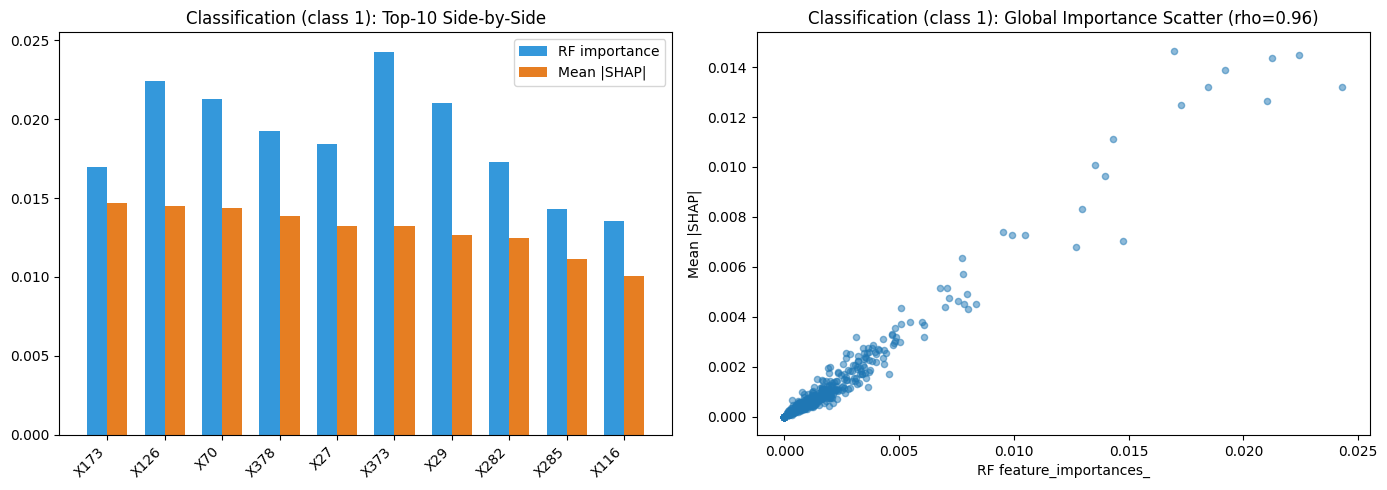


=== Interpretation ===

[회귀] Top-10 완전 일치 (9/10), Spearman=0.950
  - RF importance와 mean |SHAP| 순위가 거의 동일
  - X10, X3, X46 등 핵심 변수에 두 방법이 동의

[분류] Top-10 중 9개 공통, Spearman=0.963
  - 대체로 순위 유사하나 4~5위 부근에서 X116 vs X119 등 미세 차이 가능
  - 클래스별 SHAP은 [:, :, 0]=class -1, [:, :, 1]=class 1 → 목표 클래스 지정 필요

[RF importance vs SHAP 차이]
1) RF importance: 전역(global), 분할 기여 합 — 방향(+/−) 정보 없음
2) SHAP: 샘플별 기여 — Summary Plot에서 방향·변수값 크기까지 확인 가능
3) 순위가 비슷해도 SHAP은 "이 샘플에서 왜 이렇게 예측됐는지" Force/Dependence로 설명 가능
4) 변수 간 상관·교호작용이 크면 두 지표 순위가 달라질 수 있음 (이번 데이터는 높은 일치)


[SHAP Summary Bar — Regression]


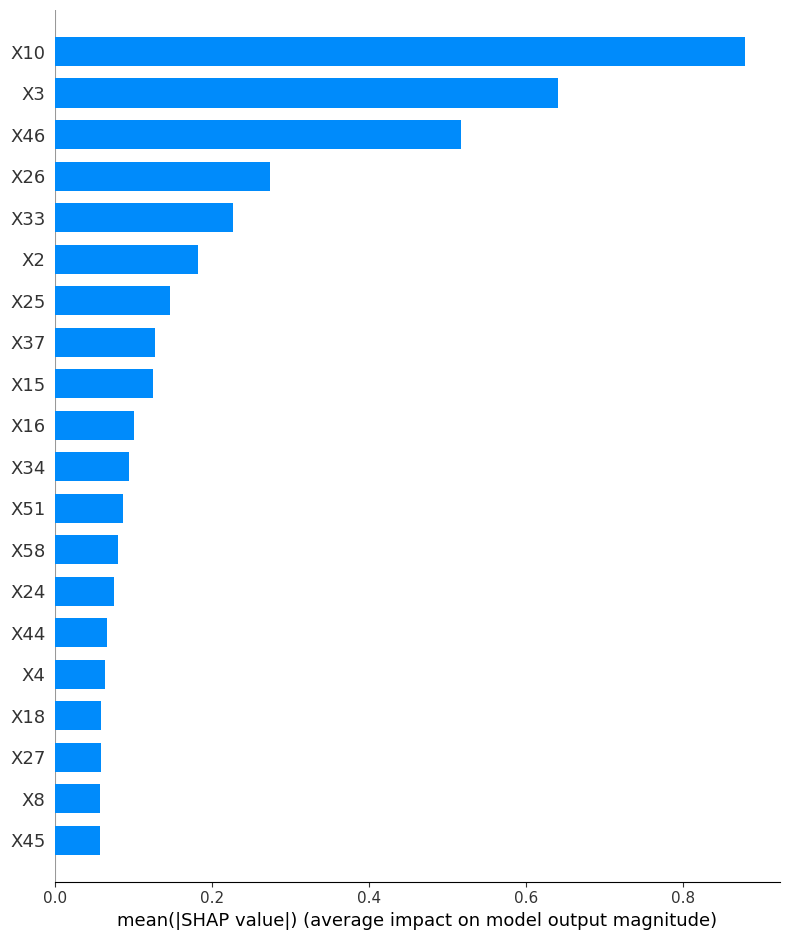

[SHAP Summary Bar — Classification class 1]


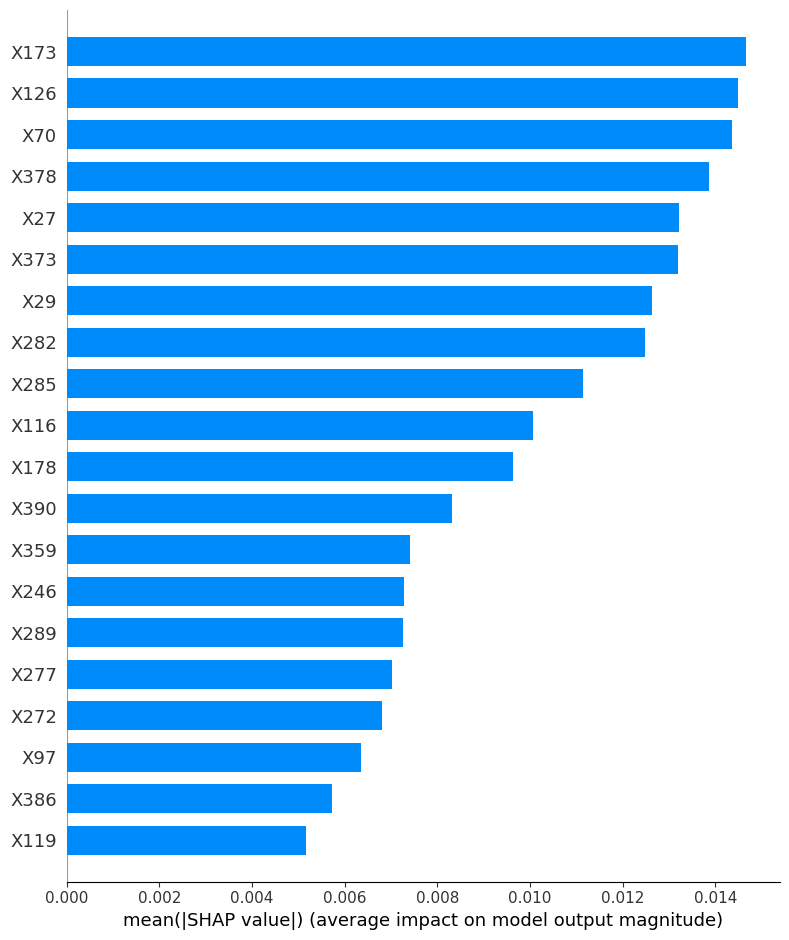

In [27]:
# [과제 1] RF feature_importances_ vs SHAP Summary 비교 (회귀 + 분류)
from scipy.stats import spearmanr

TOP_N = 10

def compare_importance(model, shap_vals, feature_names, title_prefix):
    """RF importance vs mean |SHAP| ranking comparison."""
    fi = pd.Series(model.feature_importances_, index=feature_names)
    shap_imp = pd.Series(np.abs(shap_vals).mean(axis=0), index=feature_names)

    fi_rank = fi.sort_values(ascending=False)
    shap_rank = shap_imp.sort_values(ascending=False)

    top_fi = fi_rank.head(TOP_N)
    top_shap = shap_rank.head(TOP_N)
    common = set(top_fi.index) & set(top_shap.index)

    compare_df = pd.DataFrame({
        "Feature": feature_names,
        "RF_importance": fi.values,
        "Mean_|SHAP|": shap_imp.values,
        "RF_rank": fi.rank(ascending=False).astype(int),
        "SHAP_rank": shap_imp.rank(ascending=False).astype(int),
    }).sort_values("Mean_|SHAP|", ascending=False)

    rho, _ = spearmanr(fi, shap_imp)

    print(f"\n=== {title_prefix} ===")
    print(f"Top-{TOP_N} overlap: {len(common)}/{TOP_N} → {sorted(common)}")
    print(f"Spearman rank correlation: {rho:.3f}")
    display(compare_df.head(TOP_N))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    top_feats = compare_df.head(TOP_N)["Feature"]
    x = np.arange(TOP_N)
    w = 0.35
    axes[0].bar(x - w/2, compare_df.set_index("Feature").loc[top_feats, "RF_importance"], w, label="RF importance", color="#3498db")
    axes[0].bar(x + w/2, compare_df.set_index("Feature").loc[top_feats, "Mean_|SHAP|"], w, label="Mean |SHAP|", color="#e67e22")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(top_feats, rotation=45, ha="right")
    axes[0].set_title(f"{title_prefix}: Top-{TOP_N} Side-by-Side")
    axes[0].legend()

    axes[1].scatter(fi, shap_imp, alpha=0.5, s=20)
    axes[1].set_xlabel("RF feature_importances_")
    axes[1].set_ylabel("Mean |SHAP|")
    axes[1].set_title(f"{title_prefix}: Global Importance Scatter (rho={rho:.2f})")
    plt.tight_layout()
    plt.show()

    return compare_df, rho, common

# --- 회귀 ---
reg_df, reg_rho, reg_common = compare_importance(
    rf_reg, shap_values_reg, X_train_reg.columns, "Regression"
)

# --- 분류 (클래스 1 기준 SHAP) ---
cls_df, cls_rho, cls_common = compare_importance(
    rf_cls, shap_values_cls[:, :, 1], X_train_cls.columns, "Classification (class 1)"
)

print("\n=== Interpretation ===")
print(f"""
[회귀] Top-{TOP_N} 완전 일치 ({len(reg_common)}/{TOP_N}), Spearman={reg_rho:.3f}
  - RF importance와 mean |SHAP| 순위가 거의 동일
  - X10, X3, X46 등 핵심 변수에 두 방법이 동의

[분류] Top-{TOP_N} 중 {len(cls_common)}개 공통, Spearman={cls_rho:.3f}
  - 대체로 순위 유사하나 4~5위 부근에서 X116 vs X119 등 미세 차이 가능
  - 클래스별 SHAP은 [:, :, 0]=class -1, [:, :, 1]=class 1 → 목표 클래스 지정 필요

[RF importance vs SHAP 차이]
1) RF importance: 전역(global), 분할 기여 합 — 방향(+/−) 정보 없음
2) SHAP: 샘플별 기여 — Summary Plot에서 방향·변수값 크기까지 확인 가능
3) 순위가 비슷해도 SHAP은 "이 샘플에서 왜 이렇게 예측됐는지" Force/Dependence로 설명 가능
4) 변수 간 상관·교호작용이 크면 두 지표 순위가 달라질 수 있음 (이번 데이터는 높은 일치)
""")

# SHAP summary bar — 회귀·분류 한 plot에 나란히
shap_bar_top_n = TOP_N

reg_shap_bar = pd.Series(
    np.abs(shap_values_reg).mean(axis=0), index=X_train_reg.columns
).sort_values(ascending=True).tail(shap_bar_top_n)

cls_shap_bar = pd.Series(
    np.abs(shap_values_cls[:, :, 1]).mean(axis=0), index=X_train_cls.columns
).sort_values(ascending=True).tail(shap_bar_top_n)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

axes[0].barh(reg_shap_bar.index, reg_shap_bar.values, color="#3498db")
axes[0].set_title(f"Regression — Top {shap_bar_top_n} Mean |SHAP|")
axes[0].set_xlabel("Mean |SHAP|")

axes[1].barh(cls_shap_bar.index, cls_shap_bar.values, color="#e67e22")
axes[1].set_title(f"Classification (class 1) — Top {shap_bar_top_n} Mean |SHAP|")
axes[1].set_xlabel("Mean |SHAP|")

fig.suptitle("SHAP Summary Bar — Regression vs Classification", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()
